In [ ]:
!pip install rdkit-pypi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 63.1 MB/s eta 0:00:00


In [ ]:
# @title Property based filtering without Pfizer
!pip install rdkit-pypi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
import warnings
warnings.filterwarnings('ignore')

# --- ADD UPLOAD SECTION HERE ---
from google.colab import files
import io

print("📁 Please upload your CSV file (must have 'smiles' column):")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"✅ Loaded {len(df)} rows from {filename}")
print("Columns:", list(df.columns))
# --- END OF UPLOAD SECTION ---

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

class DrugAnalyzerSequential:
    def __init__(self, dataframe):
        self.df = dataframe.copy()
        self.original_count = len(dataframe)
        self.filtering_results = {}

    def calculate_properties(self):
        """Calculate molecular properties for all compounds"""
        print("🧮 Calculating molecular properties...")

        properties = []
        invalid_smiles = 0

        for idx, smiles in enumerate(self.df['smiles']):
            try:
                mol = Chem.MolFromSmiles(str(smiles)) if pd.notna(smiles) else None

                if mol is None:
                    invalid_smiles += 1
                    prop = {key: np.nan for key in ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Rings', 'HeavyAtoms', 'LogS']}
                else:
                    # Calculate all molecular descriptors
                    prop = {
                        'MW': Descriptors.MolWt(mol),
                        'LogP': Crippen.MolLogP(mol),
                        'HBD': Lipinski.NumHDonors(mol),
                        'HBA': Lipinski.NumHAcceptors(mol),
                        'TPSA': Descriptors.TPSA(mol),
                        'RotBonds': Descriptors.NumRotatableBonds(mol),
                        'Rings': rdMolDescriptors.CalcNumRings(mol),
                        'HeavyAtoms': mol.GetNumHeavyAtoms(),
                        'LogS': self.calculate_logS(mol)  # Improved LogS calculation
                    }

            except Exception as e:
                invalid_smiles += 1
                prop = {key: np.nan for key in ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Rings', 'HeavyAtoms', 'LogS']}

            properties.append(prop)

            # Progress indicator
            if (idx + 1) % 100 == 0:
                print(f"  Processed {idx + 1}/{len(self.df)} compounds...")

        # Add properties to dataframe
        for key in properties[0].keys():
            self.df[key] = [prop[key] for prop in properties]

        print(f"✅ Properties calculated! ({invalid_smiles} invalid SMILES found)")
        return self.df

    def calculate_logS(self, mol):
        """Improved LogS calculation using ESOL method"""
        try:
            # ESOL (Estimated SOLubility) method
            logP = Crippen.MolLogP(mol)
            MW = Descriptors.MolWt(mol)
            RB = Descriptors.NumRotatableBonds(mol)
            AP = rdMolDescriptors.CalcNumAromaticRings(mol)

            # ESOL equation
            logS = 0.16 - 0.63*logP - 0.0062*MW + 0.066*RB - 0.74*AP
            return logS
        except:
            return np.nan

    def apply_rule_filter(self, df, rule_name, conditions):
        """Apply a set of conditions and return filtered dataframe"""
        try:
            # Combine all conditions with AND logic
            combined_mask = np.ones(len(df), dtype=bool)
            for condition in conditions:
                # Handle NaN values by treating them as failures
                condition_mask = condition.fillna(False) if hasattr(condition, 'fillna') else condition
                combined_mask = combined_mask & condition_mask

            filtered_df = df.loc[combined_mask].copy()
            passed_count = len(filtered_df)
            failed_count = len(df) - passed_count

            print(f"  {rule_name}: {passed_count} passed, {failed_count} failed")
            return filtered_df

        except Exception as e:
            print(f"  Error in {rule_name} filter: {e}")
            return df

    def apply_REOS_filter(self, df):
        """Apply REOS (Rapid Elimination Of Swill) filter"""
        print("🚫 Applying REOS filter...")

        # REOS unwanted substructures
        REOS_patterns = [
            '[#7][#7]',           # Azo groups
            '[#6]=[#7][#7]',      # Hydrazones
            '[#16]=[#16]',        # Disulfides
            '[#7]=[#7]',          # Azo
            '[#6]#[#7]',          # Nitriles (optional)
            '[#7][#16]',          # N-S bonds
            '[#16]=[#8]',         # Sulfoxides
            '[#15]',              # Phosphorus
            '[#9,#17,#35,#53]',   # Halogens (optional, can be removed)
            '[#33,#51,#83]',      # Metalloids
        ]

        reos_flags = []
        for smiles in df['smiles']:
            try:
                mol = Chem.MolFromSmiles(str(smiles)) if pd.notna(smiles) else None
                passes_reos = True

                if mol is not None:
                    for pattern in REOS_patterns:
                        try:
                            if mol.HasSubstructMatch(Chem.MolFromSmarts(pattern)):
                                passes_reos = False
                                break
                        except:
                            continue
                else:
                    passes_reos = False

                reos_flags.append(passes_reos)

            except Exception as e:
                reos_flags.append(False)

        filtered_df = df.loc[reos_flags].copy()
        passed_count = len(filtered_df)
        failed_count = len(df) - passed_count

        print(f"  REOS filter: {passed_count} passed, {failed_count} failed")
        return filtered_df

    def predict_toxicity_filter(self, df):
        """Apply toxicity prediction filter"""
        print("☠️ Applying toxicity filter...")

        # Structural alerts for toxicity
        toxic_patterns = [
            '[N+](=O)[O-]',       # Nitro groups
            '[CH]=O',             # Aldehydes
            'C1OC1',              # Epoxides
            'c[NH2]',             # Aromatic amines
            'N-N',                # Hydrazines
            '[SH]',               # Thiols
            'C=C-C=O',            # α,β-unsaturated carbonyls
            '[Cl,Br,I][CH2]',     # Alkyl halides
        ]

        toxicity_scores = []
        for idx, smiles in enumerate(df['smiles']):
            try:
                mol = Chem.MolFromSmiles(str(smiles)) if pd.notna(smiles) else None
                score = 0

                if mol is not None:
                    # Check structural alerts
                    for pattern in toxic_patterns:
                        try:
                            if mol.HasSubstructMatch(Chem.MolFromSmarts(pattern)):
                                score += 1
                        except:
                            continue

                    # Additional property-based toxicity indicators
                    row_idx = df.index[idx]
                    if not pd.isna(df.loc[row_idx, 'MW']) and df.loc[row_idx, 'MW'] > 800:
                        score += 1
                    if not pd.isna(df.loc[row_idx, 'LogP']) and df.loc[row_idx, 'LogP'] > 6:
                        score += 1
                    if not pd.isna(df.loc[row_idx, 'TPSA']) and df.loc[row_idx, 'TPSA'] > 200:
                        score += 1

                toxicity_scores.append(score)

            except Exception as e:
                toxicity_scores.append(10)  # Assume toxic if error

        # Filter out compounds with toxicity score >= 2
        df['Toxicity_Score'] = toxicity_scores
        filtered_df = df.loc[df['Toxicity_Score'] < 2].copy()

        passed_count = len(filtered_df)
        failed_count = len(df) - passed_count

        print(f"  Toxicity filter: {passed_count} passed, {failed_count} failed")
        return filtered_df

    def analyze_sequential(self):
        """Perform sequential drug-likeness filtering"""
        print("🔬 Starting sequential drug-likeness analysis...")
        print(f"📊 Initial dataset: {self.original_count} compounds\n")

        # Calculate properties
        self.calculate_properties()

        # Remove compounds with missing critical properties
        initial_df = self.df.dropna(subset=['MW', 'LogP', 'HBD', 'HBA']).copy()
        print(f"After removing invalid compounds: {len(initial_df)} compounds\n")

        current_df = initial_df.copy()
        self.filtering_results['Initial'] = len(current_df)

        # Define drug-likeness rules with proper condition evaluation
        rules_config = {
            'Lipinski (Rule of 5)': {
                'MW': ('<=', 500),
                'LogP': ('<=', 5),
                'HBD': ('<=', 5),
                'HBA': ('<=', 10)
            },
            'Veber': {
                'TPSA': ('<=', 140),
                'RotBonds': ('<=', 10)
            },
            'Ghose': {
                'MW': ('range', 160, 480),
                'LogP': ('range', -0.4, 5.6),
                'HeavyAtoms': ('<=', 50)
            },
            'Egan': {
                'TPSA': ('<=', 131.6),
                'LogP': ('range', -1, 6)
            },
            'Muegge': {
                'MW': ('range', 200, 600),
                'LogP': ('range', -2, 5),
                'TPSA': ('<=', 150),
                'Rings': ('<=', 7),
                'HBD': ('<=', 5),
                'HBA': ('<=', 10),
                'RotBonds': ('<=', 15)
            }
        }

        # Apply each rule sequentially
        for rule_name, rule_conditions in rules_config.items():
            print(f"Applying {rule_name}...")

            # Build conditions for current dataframe
            conditions = []
            for prop, condition in rule_conditions.items():
                if condition[0] == '<=':
                    conditions.append(current_df[prop] <= condition[1])
                elif condition[0] == '>=':
                    conditions.append(current_df[prop] >= condition[1])
                elif condition[0] == 'range':
                    conditions.append((current_df[prop] >= condition[1]) & (current_df[prop] <= condition[2]))

            current_df = self.apply_rule_filter(current_df, rule_name, conditions)
            self.filtering_results[rule_name] = len(current_df)

        # Apply solubility filter
        print("Applying Solubility filter...")
        soluble_mask = current_df['LogS'] > -4
        current_df = current_df.loc[soluble_mask.fillna(False)].copy()
        self.filtering_results['Soluble (LogS > -4)'] = len(current_df)
        print(f"  Solubility filter: {len(current_df)} passed")

        # Apply toxicity filter
        current_df = self.predict_toxicity_filter(current_df)
        self.filtering_results['Non-Toxic'] = len(current_df)

        # Apply REOS filter
        current_df = self.apply_REOS_filter(current_df)
        self.filtering_results['REOS'] = len(current_df)

        print(f"\n✅ Sequential filtering complete!")
        print(f"📊 Final result: {len(current_df)} compounds passed all filters")
        print(f"📉 Filtering efficiency: {len(current_df)/self.original_count*100:.1f}%")

        return current_df, self.filtering_results

    def create_visualizations(self, final_df, filtering_results):
        """Create comprehensive visualizations"""
        print("\n📊 Creating visualizations...")

        # Set up the plotting area
        fig = plt.figure(figsize=(20, 15))

        # 1. Filtering cascade plot
        plt.subplot(3, 4, 1)
        steps = list(filtering_results.keys())
        counts = list(filtering_results.values())
        colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))

        bars = plt.bar(range(len(steps)), counts, color=colors)
        plt.title('Sequential Filtering Results', fontsize=14, fontweight='bold')
        plt.xlabel('Filtering Step')
        plt.ylabel('Number of Compounds')
        plt.xticks(range(len(steps)), steps, rotation=45, ha='right')

        # Add value labels on bars
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                    str(count), ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()

        # 2. Property distributions (before and after)
        properties = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds']

        for i, prop in enumerate(properties):
            plt.subplot(3, 4, i+2)

            # Original data
            original_data = self.df[prop].dropna()
            final_data = final_df[prop].dropna()

            if len(original_data) > 0:
                plt.hist(original_data, bins=30, alpha=0.5, label='Original', color='lightcoral', density=True)
            if len(final_data) > 0:
                plt.hist(final_data, bins=30, alpha=0.7, label='Filtered', color='steelblue', density=True)

            plt.title(f'{prop} Distribution', fontweight='bold')
            plt.xlabel(prop)
            plt.ylabel('Density')
            plt.legend()
            plt.grid(True, alpha=0.3)

        # 3. Correlation heatmap
        plt.subplot(3, 4, 8)
        correlation_props = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'LogS']
        available_props = [prop for prop in correlation_props if prop in final_df.columns]

        if len(available_props) > 1 and len(final_df) > 1:
            corr_matrix = final_df[available_props].corr()
            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                       square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title('Property Correlations (Filtered Data)', fontweight='bold')

        # 4. Drug-likeness space plot
        plt.subplot(3, 4, 9)
        original_mw = self.df['MW'].dropna()
        original_logp = self.df['LogP'].dropna()
        final_mw = final_df['MW'].dropna()
        final_logp = final_df['LogP'].dropna()

        if len(original_mw) > 0 and len(original_logp) > 0:
            plt.scatter(original_mw, original_logp, alpha=0.5, s=20, color='lightcoral', label='Original')
        if len(final_mw) > 0 and len(final_logp) > 0:
            plt.scatter(final_mw, final_logp, alpha=0.8, s=30, color='steelblue', label='Filtered')

        # Add Lipinski boundaries
        plt.axvline(x=500, color='red', linestyle='--', alpha=0.7, label='MW=500')
        plt.axhline(y=5, color='red', linestyle='--', alpha=0.7, label='LogP=5')

        plt.xlabel('Molecular Weight')
        plt.ylabel('LogP')
        plt.title('Drug-likeness Space (MW vs LogP)', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 5. Solubility vs Permeability
        plt.subplot(3, 4, 10)
        final_logs = final_df['LogS'].dropna()
        final_tpsa = final_df['TPSA'].dropna()

        if len(final_logs) > 0 and len(final_tpsa) > 0:
            plt.scatter(final_logs, final_tpsa, alpha=0.7, s=30, color='green')

        plt.axvline(x=-4, color='red', linestyle='--', alpha=0.7, label='LogS=-4')
        plt.axhline(y=140, color='red', linestyle='--', alpha=0.7, label='TPSA=140')

        plt.xlabel('LogS (Solubility)')
        plt.ylabel('TPSA (Permeability)')
        plt.title('Solubility vs Permeability', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 6. Summary statistics
        plt.subplot(3, 4, 11)
        plt.axis('off')

        # Calculate summary stats carefully to handle empty DataFrame or NaN values
        mean_mw = final_df['MW'].mean() if len(final_df) > 0 and not final_df['MW'].dropna().empty else 'N/A'
        mean_logp = final_df['LogP'].mean() if len(final_df) > 0 and not final_df['LogP'].dropna().empty else 'N/A'
        mean_tpsa = final_df['TPSA'].mean() if len(final_df) > 0 and not final_df['TPSA'].dropna().empty else 'N/A'
        mean_logs = final_df['LogS'].mean() if len(final_df) > 0 and not final_df['LogS'].dropna().empty else 'N/A'

        # Format values only if they are numbers, otherwise keep 'N/A'
        mean_mw_str = f"{mean_mw:.1f}" if isinstance(mean_mw, (int, float)) else mean_mw
        mean_logp_str = f"{mean_logp:.2f}" if isinstance(mean_logp, (int, float)) else mean_logp
        mean_tpsa_str = f"{mean_tpsa:.1f}" if isinstance(mean_tpsa, (int, float)) else mean_tpsa
        mean_logs_str = f"{mean_logs:.2f}" if isinstance(mean_logs, (int, float)) else mean_logs


        summary_text = f"""
        FILTERING SUMMARY

        Initial compounds: {self.original_count}
        Final compounds: {len(final_df)}
        Success rate: {len(final_df)/self.original_count*100:.1f}%

        FINAL DATASET STATS
        Mean MW: {mean_mw_str}
        Mean LogP: {mean_logp_str}
        Mean TPSA: {mean_tpsa_str}
        Mean LogS: {mean_logs_str}

        DRUG-LIKENESS
        Lipinski compliant: {len(final_df)}
        Veber compliant: {len(final_df)}
        Non-toxic: {len(final_df)}
        REOS clean: {len(final_df)}
        """

        plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

        # 7. Filtering efficiency pie chart
        plt.subplot(3, 4, 12)
        passed = len(final_df)
        failed = self.original_count - passed

        plt.pie([passed, failed], labels=['Passed', 'Failed'],
               colors=['lightgreen', 'lightcoral'], autopct='%1.1f%%',
               startangle=90)
        plt.title('Overall Filtering Efficiency', fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Create a detailed filtering cascade plot
        self.create_cascade_plot(filtering_results)

    def create_cascade_plot(self, filtering_results):
        """Create a detailed cascade/waterfall plot"""
        fig, ax = plt.subplots(figsize=(14, 8))

        steps = list(filtering_results.keys())
        counts = list(filtering_results.values())

        # Calculate drops
        drops = [counts[i] - counts[i+1] if i < len(counts)-1 else 0 for i in range(len(counts))]

        # Create waterfall effect
        x_pos = range(len(steps))
        colors = ['steelblue' if i == 0 else 'lightcoral' for i in range(len(steps))]

        bars = ax.bar(x_pos, counts, color=colors, alpha=0.7, edgecolor='black')

        # Add connecting lines
        for i in range(len(steps)-1):
            if i+1 < len(x_pos):
                ax.plot([i+0.4, i+0.6], [counts[i+1], counts[i+1]], 'k--', alpha=0.5)

        # Add labels
        for i, (bar, count, drop) in enumerate(zip(bars, counts, drops)):
            # Count label
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                   str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

            # Drop label
            if drop > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                       f'-{drop}', ha='center', va='center',
                       color='white', fontweight='bold', fontsize=9)

        ax.set_xlabel('Filtering Steps', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Compounds', fontsize=12, fontweight='bold')
        ax.set_title('Drug-Likeness Filtering Cascade', fontsize=16, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(steps, rotation=45, ha='right')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def generate_summary_report(self, final_df, filtering_results):
        """Generate detailed text summary report"""
        print("\n📝 Generating summary report...")

        # Create detailed summary
        summary_lines = []
        summary_lines.append("=" * 80)
        summary_lines.append("DRUG-LIKENESS ANALYSIS SUMMARY REPORT")
        summary_lines.append("=" * 80)
        summary_lines.append("")

        # Overview
        summary_lines.append("OVERVIEW:")
        summary_lines.append("-" * 40)
        summary_lines.append(f"Initial Dataset Size: {self.original_count} compounds")
        summary_lines.append(f"Final Dataset Size: {len(final_df)} compounds")
        summary_lines.append(f"Overall Success Rate: {len(final_df)/self.original_count*100:.2f}%")
        summary_lines.append(f"Compounds Filtered Out: {self.original_count - len(final_df)}")
        summary_lines.append("")

        # Sequential filtering results
        summary_lines.append("SEQUENTIAL FILTERING RESULTS:")
        summary_lines.append("-" * 40)
        prev_count = self.original_count
        for step, count in filtering_results.items():
            removed = prev_count - count
            retention_rate = (count / prev_count * 100) if prev_count > 0 else 0
            summary_lines.append(f"{step:<25}: {count:>6} compounds ({retention_rate:>5.1f}% retained, {removed:>5} removed)")
            prev_count = count
        summary_lines.append("")

        # Property statistics
        if len(final_df) > 0:
            summary_lines.append("FINAL DATASET MOLECULAR PROPERTIES:")
            summary_lines.append("-" * 40)
            properties = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Rings', 'HeavyAtoms', 'LogS']
            for prop in properties:
                if prop in final_df.columns:
                    prop_data = final_df[prop].dropna()
                    if len(prop_data) > 0:
                        summary_lines.append(f"{prop:<12}: Mean={prop_data.mean():>7.2f}, Std={prop_data.std():>7.2f}, Min={prop_data.min():>7.2f}, Max={prop_data.max():>7.2f}")
                    else:
                        summary_lines.append(f"{prop:<12}: No valid data")
            summary_lines.append("")

        # Drug-likeness compliance
        summary_lines.append("DRUG-LIKENESS RULE COMPLIANCE:")
        summary_lines.append("-" * 40)
        if len(final_df) > 0:
            # All compounds in final_df passed all rules by definition
            summary_lines.append(f"Lipinski Rule of 5 Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Veber Rule Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Ghose Rule Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Egan Rule Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Muegge Rule Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Non-Toxic: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"REOS Clean: {len(final_df)} compounds (100.0%)")
        else:
            summary_lines.append("No compounds passed all filters")
        summary_lines.append("")

        # Detailed rule descriptions
        summary_lines.append("DRUG-LIKENESS RULES APPLIED:")
        summary_lines.append("-" * 40)
        summary_lines.append("1. Lipinski Rule of 5:")
        summary_lines.append("   - Molecular Weight ≤ 500 Da")
        summary_lines.append("   - LogP ≤ 5")
        summary_lines.append("   - Hydrogen Bond Donors ≤ 5")
        summary_lines.append("   - Hydrogen Bond Acceptors ≤ 10")
        summary_lines.append("")
        summary_lines.append("2. Veber Rule:")
        summary_lines.append("   - Topological Polar Surface Area ≤ 140 Ų")
        summary_lines.append("   - Rotatable Bonds ≤ 10")
        summary_lines.append("")
        summary_lines.append("3. Ghose Rule:")
        summary_lines.append("   - Molecular Weight: 160-480 Da")
        summary_lines.append("   - LogP: -0.4 to 5.6")
        summary_lines.append("   - Heavy Atoms ≤ 50")
        summary_lines.append("")
        summary_lines.append("4. Egan Rule:")
        summary_lines.append("   - TPSA ≤ 131.6 Ų")
        summary_lines.append("   - LogP: -1 to 6")
        summary_lines.append("")
        summary_lines.append("5. Muegge Rule:")
        summary_lines.append("   - Molecular Weight: 200-600 Da")
        summary_lines.append("   - LogP: -2 to 5")
        summary_lines.append("   - TPSA ≤ 150 Ų")
        summary_lines.append("   - Rings ≤ 7")
        summary_lines.append("   - HBD ≤ 5, HBA ≤ 10")
        summary_lines.append("   - Rotatable Bonds ≤ 15")
        summary_lines.append("")
        summary_lines.append("6. Solubility Filter:")
        summary_lines.append("   - LogS > -4 (soluble compounds)")
        summary_lines.append("")
        summary_lines.append("7. Toxicity Filter:")
        summary_lines.append("   - Removes compounds with known toxic substructures")
        summary_lines.append("   - Filters based on structural alerts")
        summary_lines.append("")
        summary_lines.append("8. REOS Filter:")
        summary_lines.append("   - Rapid Elimination of Swill")
        summary_lines.append("   - Removes reactive and problematic substructures")
        summary_lines.append("")

        # Analysis conclusions
        summary_lines.append("ANALYSIS CONCLUSIONS:")
        summary_lines.append("-" * 40)
        if len(final_df) > 0:
            success_rate = len(final_df)/self.original_count*100
            if success_rate > 20:
                summary_lines.append("✅ GOOD: High retention rate suggests quality input dataset")
            elif success_rate > 5:
                summary_lines.append("⚠️  MODERATE: Moderate retention rate, some optimization may be needed")
            else:
                summary_lines.append("❌ LOW: Low retention rate suggests input dataset needs improvement")

            summary_lines.append(f"Final dataset contains {len(final_df)} drug-like compounds")
            summary_lines.append("All compounds passed comprehensive drug-likeness filters")
            summary_lines.append("Ready for further drug discovery applications")
        else:
            summary_lines.append("❌ CRITICAL: No compounds passed all filters")
            summary_lines.append("Consider relaxing filter criteria or improving input dataset quality")

        summary_lines.append("")
        summary_lines.append("=" * 80)
        summary_lines.append("END OF REPORT")
        summary_lines.append("=" * 80)

        # Join all lines
        summary_text = "\n".join(summary_lines)

        return summary_text

    def save_results(self, final_df, filtering_results):
        """Save CSV and summary text files"""
        print("\n💾 Saving results...")

        # Save filtered compounds to CSV
        csv_filename = "filtered_drug_like_compounds.csv"
        final_df.to_csv(csv_filename, index=False)
        print(f"✅ Saved filtered compounds to: {csv_filename}")

        # Generate and save summary report
        summary_text = self.generate_summary_report(final_df, filtering_results)
        txt_filename = "drug_analysis_summary.txt"
        with open(txt_filename, 'w') as f:
            f.write(summary_text)
        print(f"✅ Saved analysis summary to: {txt_filename}")

        # Download files in Colab
        try:
            files.download(csv_filename)
            files.download(txt_filename)
            print("📥 Files downloaded successfully!")
        except Exception as e:
            print(f"⚠️  Download error: {e}")
            print("Files are saved in the current directory")

        return csv_filename, txt_filename

# ==============================
# YOUR CODE STARTS HERE 👇👇👇
# ==============================

# Run the analysis on the uploaded dataframe 'df'
analyzer = DrugAnalyzerSequential(df)
final_df, filtering_results = analyzer.analyze_sequential()
analyzer.create_visualizations(final_df, filtering_results)

# Save results to files
csv_file, txt_file = analyzer.save_results(final_df, filtering_results)

print(f"\n🎉 Analysis Complete!")
print(f"📊 Final Results: {len(final_df)} compounds passed all filters")
print(f"📁 Output Files:")
print(f"   - CSV: {csv_file}")
print(f"   - Summary: {txt_file}")

# Display first few rows of final results
if len(final_df) > 0:
    print(f"\n📋 Preview of Final Dataset (first 5 compounds):")
    display_cols = ['smiles', 'MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'LogS']
    available_cols = [col for col in display_cols if col in final_df.columns]
    print(final_df[available_cols].head())
else:
    print("\n❌ No compounds passed all filters")

# ==============================
# YOUR CODE ENDS HERE 👆👆👆
# ==============================

In [ ]:
# @title Download All PNG files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Import pandas

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

def save_and_download(fig, filename, dpi=300):
    fig.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    if COLAB:
        try:
            files.download(filename)
        except Exception as e:
            print(f"Download error: {e}")
    print(f"✅ Saved: {filename}")

# Modified function signature to accept the dataframe containing calculated properties
def generate_and_save_all_visualizations(original_df_with_properties, final_df, filtering_results, original_count):
    # 1. Filtering cascade plot
    fig1 = plt.figure(figsize=(8, 6))
    steps = list(filtering_results.keys())
    counts = list(filtering_results.values())
    colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))
    bars = plt.bar(range(len(steps)), counts, color=colors)
    plt.title('Sequential Filtering Results', fontsize=14, fontweight='bold')
    plt.xlabel('Filtering Step')
    plt.ylabel('Number of Compounds')
    plt.xticks(range(len(steps)), steps, rotation=45, ha='right')
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                str(count), ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    save_and_download(fig1, 'panel_filtering_cascade.png')

    # 2. Property distributions (before and after)
    properties = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds']
    for prop in properties:
        # Check if the property column exists in both dataframes
        if prop in original_df_with_properties.columns and prop in final_df.columns:
            fig2 = plt.figure(figsize=(8, 6))
            # Use the dataframe with calculated properties for 'Original' data
            original_data = original_df_with_properties[prop].dropna()
            final_data = final_df[prop].dropna()
            if len(original_data) > 0:
                plt.hist(original_data, bins=30, alpha=0.5, label='Original', color='lightcoral', density=True)
            if len(final_data) > 0:
                plt.hist(final_data, bins=30, alpha=0.7, label='Filtered', color='steelblue', density=True)
            plt.title(f'{prop} Distribution', fontweight='bold')
            plt.xlabel(prop)
            plt.ylabel('Density')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            save_and_download(fig2, f'panel_hist_{prop}.png')
        else:
            print(f"Warning: Property '{prop}' not found in one or both dataframes. Skipping histogram.")


    # 3. Correlation heatmap
    fig3 = plt.figure(figsize=(8, 6))
    correlation_props = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'LogS']
    # Ensure properties exist in final_df before trying to correlate
    available_props = [prop for prop in correlation_props if prop in final_df.columns]

    if len(available_props) > 1 and len(final_df) > 1:
        # Calculate correlations only for available and numeric properties
        corr_matrix = final_df[available_props].corr(numeric_only=True)
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                   square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title('Property Correlations (Filtered Data)', fontweight='bold')
        plt.tight_layout()
        save_and_download(fig3, 'panel_correlation_heatmap.png')
    else:
         print("Warning: Not enough numeric columns in final_df to plot correlation heatmap.")


    # 4. Drug-likeness space plot
    fig4 = plt.figure(figsize=(8, 6))
    # Use the dataframe with calculated properties for 'Original' data
    # Check if MW and LogP exist before plotting
    if 'MW' in original_df_with_properties.columns and 'LogP' in original_df_with_properties.columns:
        original_mw = original_df_with_properties['MW'].dropna()
        original_logp = original_df_with_properties['LogP'].dropna()
        if len(original_mw) > 0 and len(original_logp) > 0:
            plt.scatter(original_mw, original_logp, alpha=0.5, s=20, color='lightcoral', label='Original')
    else:
        print("Warning: 'MW' or 'LogP' not found in original_df_with_properties. Skipping original scatter points.")

    if 'MW' in final_df.columns and 'LogP' in final_df.columns:
        final_mw = final_df['MW'].dropna()
        final_logp = final_df['LogP'].dropna()
        if len(final_mw) > 0 and len(final_logp) > 0:
            plt.scatter(final_mw, final_logp, alpha=0.8, s=30, color='steelblue', label='Filtered')
    else:
         print("Warning: 'MW' or 'LogP' not found in final_df. Skipping filtered scatter points.")


    # Add Lipinski boundaries
    plt.axvline(x=500, color='red', linestyle='--', alpha=0.7, label='MW=500')
    plt.axhline(y=5, color='red', linestyle='--', alpha=0.7, label='LogP=5')

    plt.xlabel('Molecular Weight')
    plt.ylabel('LogP')
    plt.title('Drug-likeness Space (MW vs LogP)', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_and_download(fig4, 'panel_druglikeness_space.png')

    # 5. Solubility vs Permeability
    fig5 = plt.figure(figsize=(8, 6))
    # Check if LogS and TPSA exist before plotting
    if 'LogS' in final_df.columns and 'TPSA' in final_df.columns:
        final_logs = final_df['LogS'].dropna()
        final_tpsa = final_df['TPSA'].dropna()
        if len(final_logs) > 0 and len(final_tpsa) > 0:
            plt.scatter(final_logs, final_tpsa, alpha=0.7, s=30, color='green')

        plt.axvline(x=-4, color='red', linestyle='--', alpha=0.7, label='LogS=-4')
        plt.axhline(y=140, color='red', linestyle='--', alpha=0.7, label='TPSA=140')

        plt.xlabel('LogS (Solubility)')
        plt.ylabel('TPSA (Permeability)')
        plt.title('Solubility vs Permeability', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_and_download(fig5, 'panel_solubility_vs_permeability.png')
    else:
        print("Warning: 'LogS' or 'TPSA' not found in final_df. Skipping Solubility vs Permeability plot.")

    # 6. Pie Chart
    fig6 = plt.figure(figsize=(8, 6))
    passed = len(final_df)
    failed = original_count - passed
    plt.pie([passed, failed], labels=['Passed', 'Failed'],
           colors=['lightgreen', 'lightcoral'], autopct='%1.1f%%',
           startangle=90)
    plt.title('Overall Filtering Efficiency', fontweight='bold')
    plt.tight_layout()
    save_and_download(fig6, 'panel_filtering_efficiency_pie.png')

    print("🎉 All panels saved as PNGs.")

# Update the call site to pass the dataframe with calculated properties (analyzer.df)
# Assuming 'analyzer' object exists from the previous cell and analysis has been run.
# The 'df' variable used here is the one *after* calling analyzer.analyze_sequential(),
# which is the analyzer.df inside the class instance after properties are added.
# Therefore, we should pass analyzer.df to the plotting function.

# Replace the existing call:
# generate_and_save_all_visualizations(df, final_df, filtering_results, original_count=len(df))

# With this corrected call:
generate_and_save_all_visualizations(analyzer.df, final_df, filtering_results, original_count=analyzer.original_count)

📁 Please upload your CSV file (must have 'smiles' column):


Saving natural and marine compound & COCONUT.csv to natural and marine compound & COCONUT (4).csv
✅ Uploaded file: natural and marine compound & COCONUT (4).csv
✅ Loaded 779558 rows from natural and marine compound & COCONUT (4).csv
Columns: ['identifier', 'smiles']
🔬 Starting sequential drug-likeness analysis...
📊 Initial dataset: 779558 compounds

🧮 Calculating molecular properties...
  Processed 100/779558 compounds...
  Processed 200/779558 compounds...
  Processed 300/779558 compounds...
  Processed 400/779558 compounds...
  Processed 500/779558 compounds...
  Processed 600/779558 compounds...
  Processed 700/779558 compounds...
  Processed 800/779558 compounds...
  Processed 900/779558 compounds...
  Processed 1000/779558 compounds...
  Processed 1100/779558 compounds...
  Processed 1200/779558 compounds...
  Processed 1300/779558 compounds...
  Processed 1400/779558 compounds...
  Processed 1500/779558 compounds...
  Processed 1600/779558 compounds...
  Processed 1700/779558 com

[11:18:03] SMILES Parse Error: syntax error while parsing: FALSE
[11:18:03] SMILES Parse Error: Failed parsing SMILES 'FALSE' for input: 'FALSE'


  Processed 114600/779558 compounds...
  Processed 114700/779558 compounds...
  Processed 114800/779558 compounds...
  Processed 114900/779558 compounds...
  Processed 115000/779558 compounds...
  Processed 115100/779558 compounds...
  Processed 115200/779558 compounds...
  Processed 115300/779558 compounds...
  Processed 115400/779558 compounds...
  Processed 115500/779558 compounds...
  Processed 115600/779558 compounds...
  Processed 115700/779558 compounds...
  Processed 115800/779558 compounds...
  Processed 115900/779558 compounds...
  Processed 116000/779558 compounds...
  Processed 116100/779558 compounds...
  Processed 116200/779558 compounds...
  Processed 116300/779558 compounds...
  Processed 116400/779558 compounds...
  Processed 116500/779558 compounds...
  Processed 116600/779558 compounds...
  Processed 116700/779558 compounds...
  Processed 116800/779558 compounds...
  Processed 116900/779558 compounds...
  Processed 117000/779558 compounds...
  Processed 117100/779558

[11:18:49] SMILES Parse Error: syntax error while parsing: FALSE
[11:18:49] SMILES Parse Error: Failed parsing SMILES 'FALSE' for input: 'FALSE'


  Processed 152500/779558 compounds...
  Processed 152600/779558 compounds...
  Processed 152700/779558 compounds...
  Processed 152800/779558 compounds...
  Processed 152900/779558 compounds...
  Processed 153000/779558 compounds...
  Processed 153100/779558 compounds...
  Processed 153200/779558 compounds...
  Processed 153300/779558 compounds...
  Processed 153400/779558 compounds...
  Processed 153500/779558 compounds...
  Processed 153600/779558 compounds...
  Processed 153700/779558 compounds...
  Processed 153800/779558 compounds...
  Processed 153900/779558 compounds...
  Processed 154000/779558 compounds...
  Processed 154100/779558 compounds...
  Processed 154200/779558 compounds...
  Processed 154300/779558 compounds...
  Processed 154400/779558 compounds...
  Processed 154500/779558 compounds...
  Processed 154600/779558 compounds...
  Processed 154700/779558 compounds...
  Processed 154800/779558 compounds...
  Processed 154900/779558 compounds...
  Processed 155000/779558

[11:22:51] WARNING: not removing hydrogen atom without neighbors


  Processed 332400/779558 compounds...
  Processed 332500/779558 compounds...
  Processed 332600/779558 compounds...
  Processed 332700/779558 compounds...
  Processed 332800/779558 compounds...
  Processed 332900/779558 compounds...
  Processed 333000/779558 compounds...
  Processed 333100/779558 compounds...
  Processed 333200/779558 compounds...
  Processed 333300/779558 compounds...
  Processed 333400/779558 compounds...
  Processed 333500/779558 compounds...
  Processed 333600/779558 compounds...
  Processed 333700/779558 compounds...
  Processed 333800/779558 compounds...
  Processed 333900/779558 compounds...
  Processed 334000/779558 compounds...
  Processed 334100/779558 compounds...
  Processed 334200/779558 compounds...
  Processed 334300/779558 compounds...
  Processed 334400/779558 compounds...
  Processed 334500/779558 compounds...
  Processed 334600/779558 compounds...
  Processed 334700/779558 compounds...
  Processed 334800/779558 compounds...
  Processed 334900/779558

[11:27:51] WARNING: not removing hydrogen atom without neighbors


  Processed 530000/779558 compounds...
  Processed 530100/779558 compounds...
  Processed 530200/779558 compounds...
  Processed 530300/779558 compounds...
  Processed 530400/779558 compounds...
  Processed 530500/779558 compounds...
  Processed 530600/779558 compounds...
  Processed 530700/779558 compounds...
  Processed 530800/779558 compounds...
  Processed 530900/779558 compounds...
  Processed 531000/779558 compounds...
  Processed 531100/779558 compounds...
  Processed 531200/779558 compounds...
  Processed 531300/779558 compounds...
  Processed 531400/779558 compounds...
  Processed 531500/779558 compounds...
  Processed 531600/779558 compounds...
  Processed 531700/779558 compounds...
  Processed 531800/779558 compounds...
  Processed 531900/779558 compounds...
  Processed 532000/779558 compounds...
  Processed 532100/779558 compounds...
  Processed 532200/779558 compounds...
  Processed 532300/779558 compounds...
  Processed 532400/779558 compounds...
  Processed 532500/779558

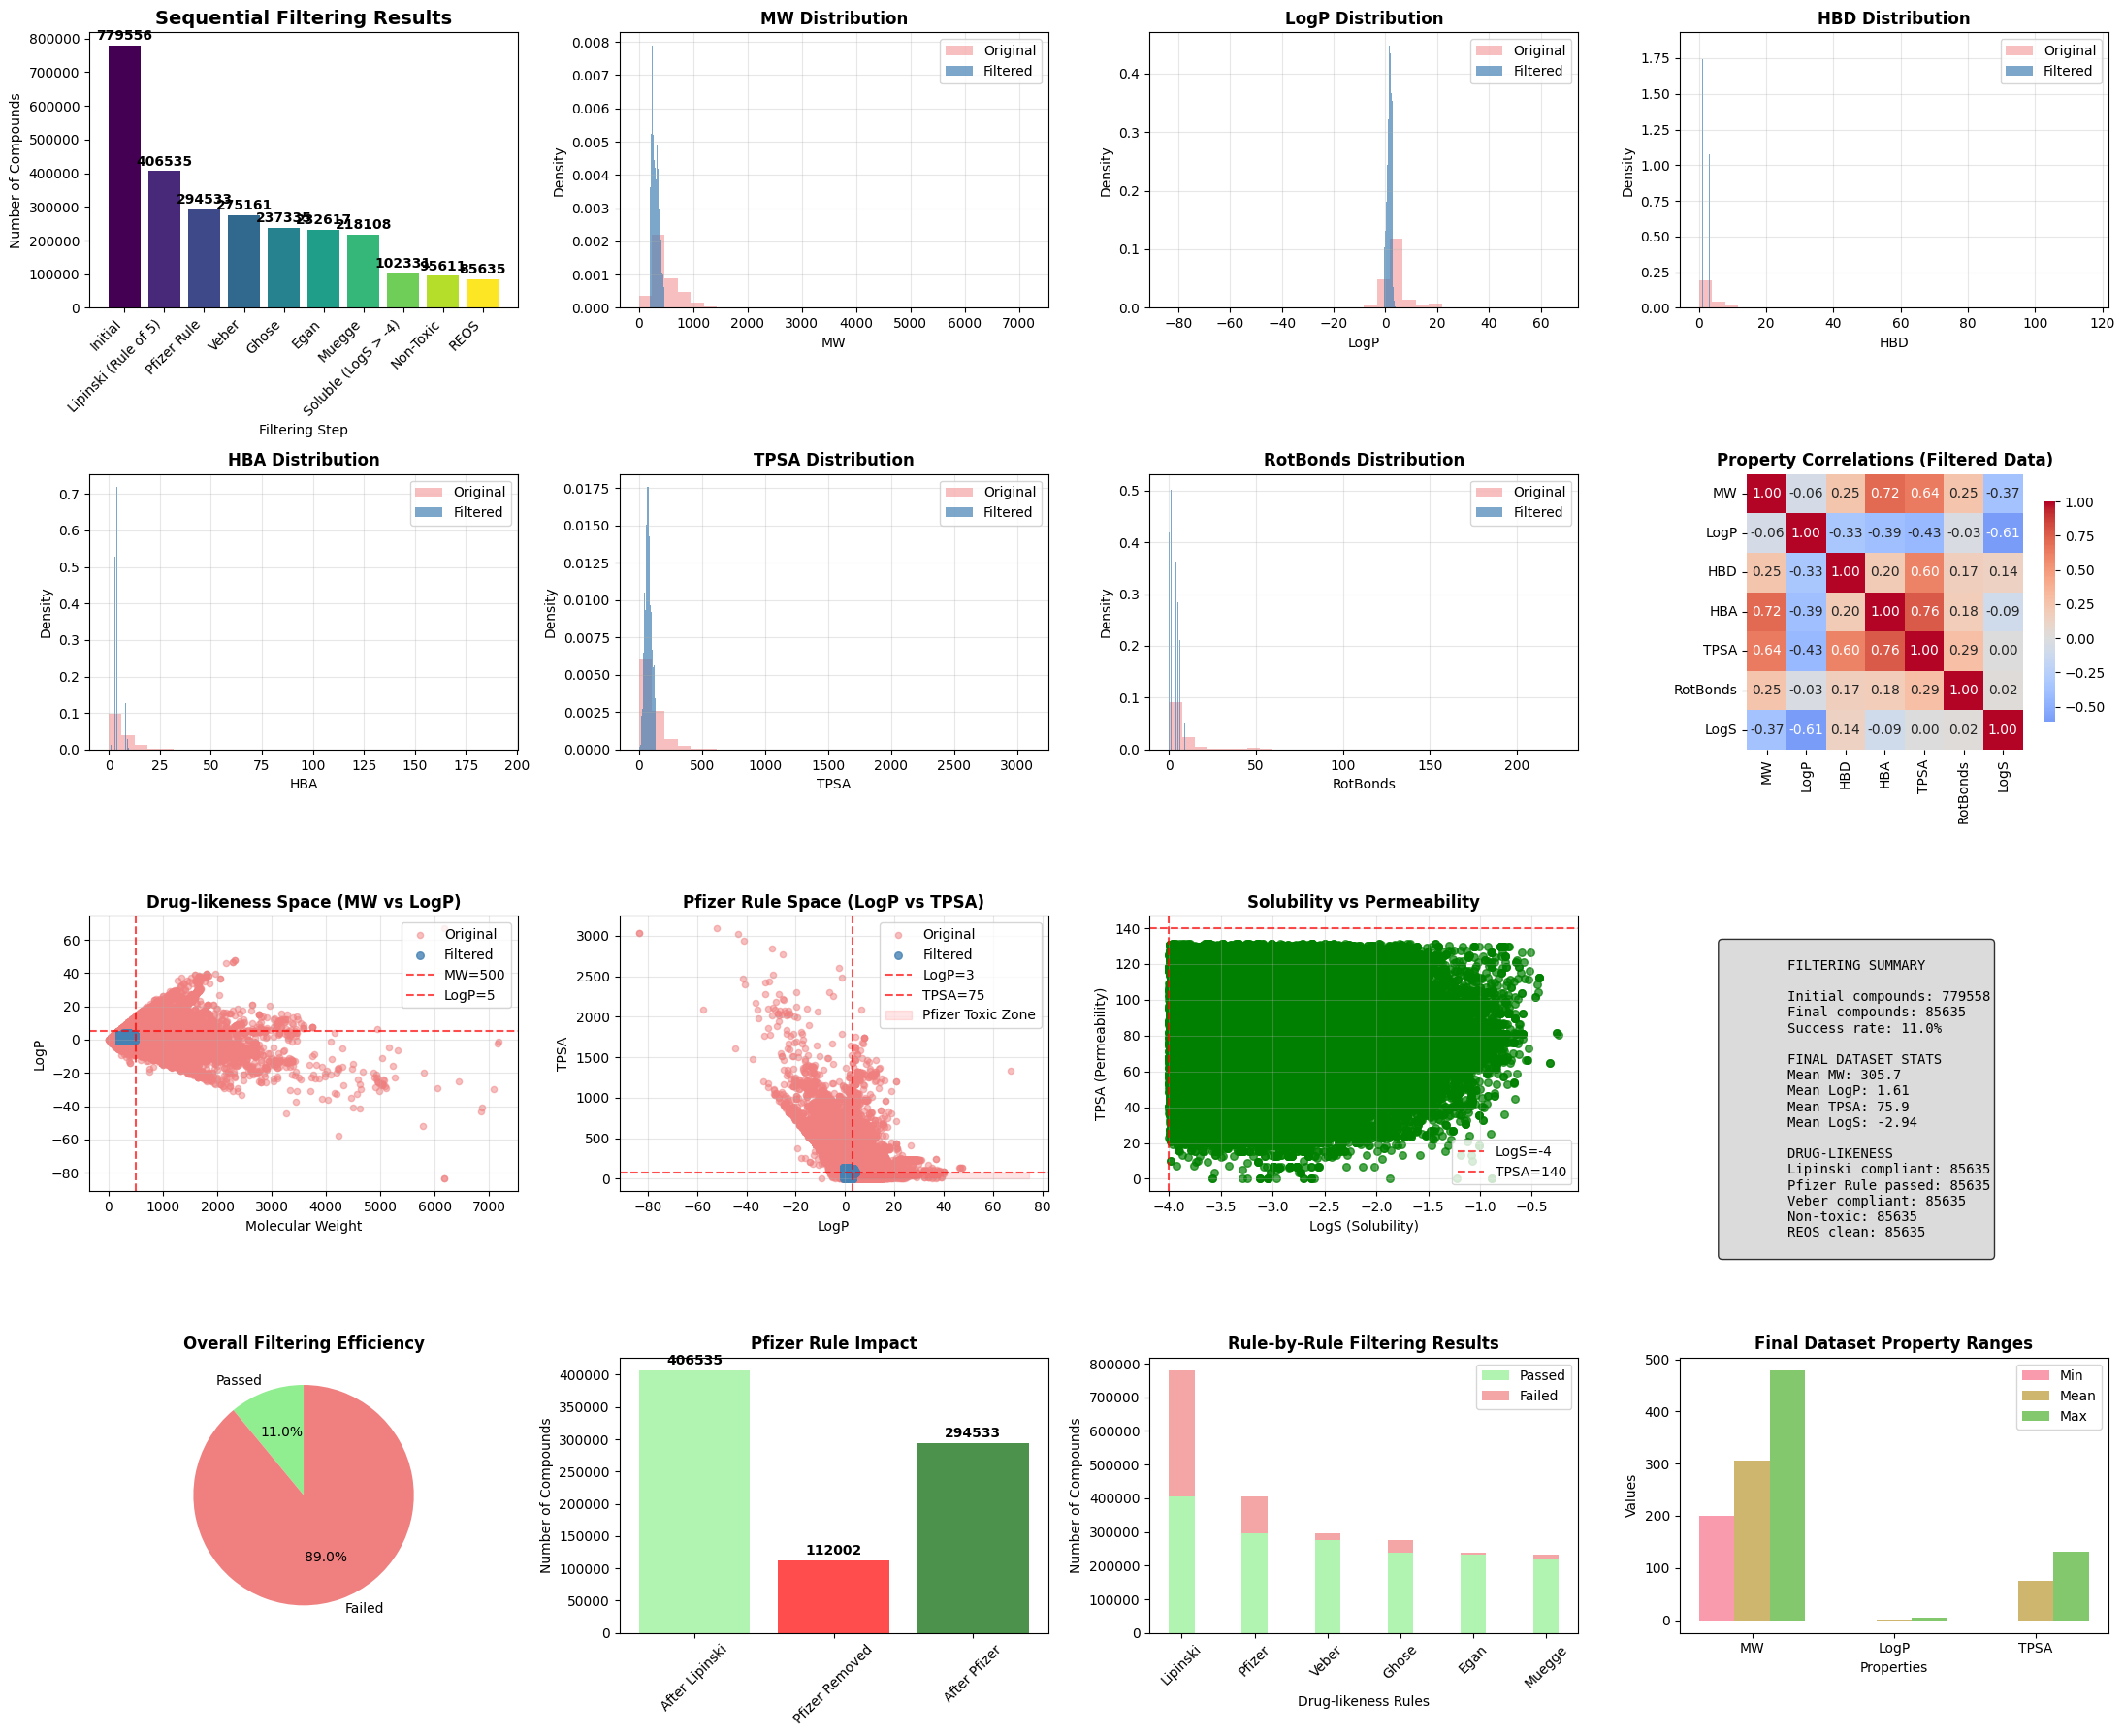

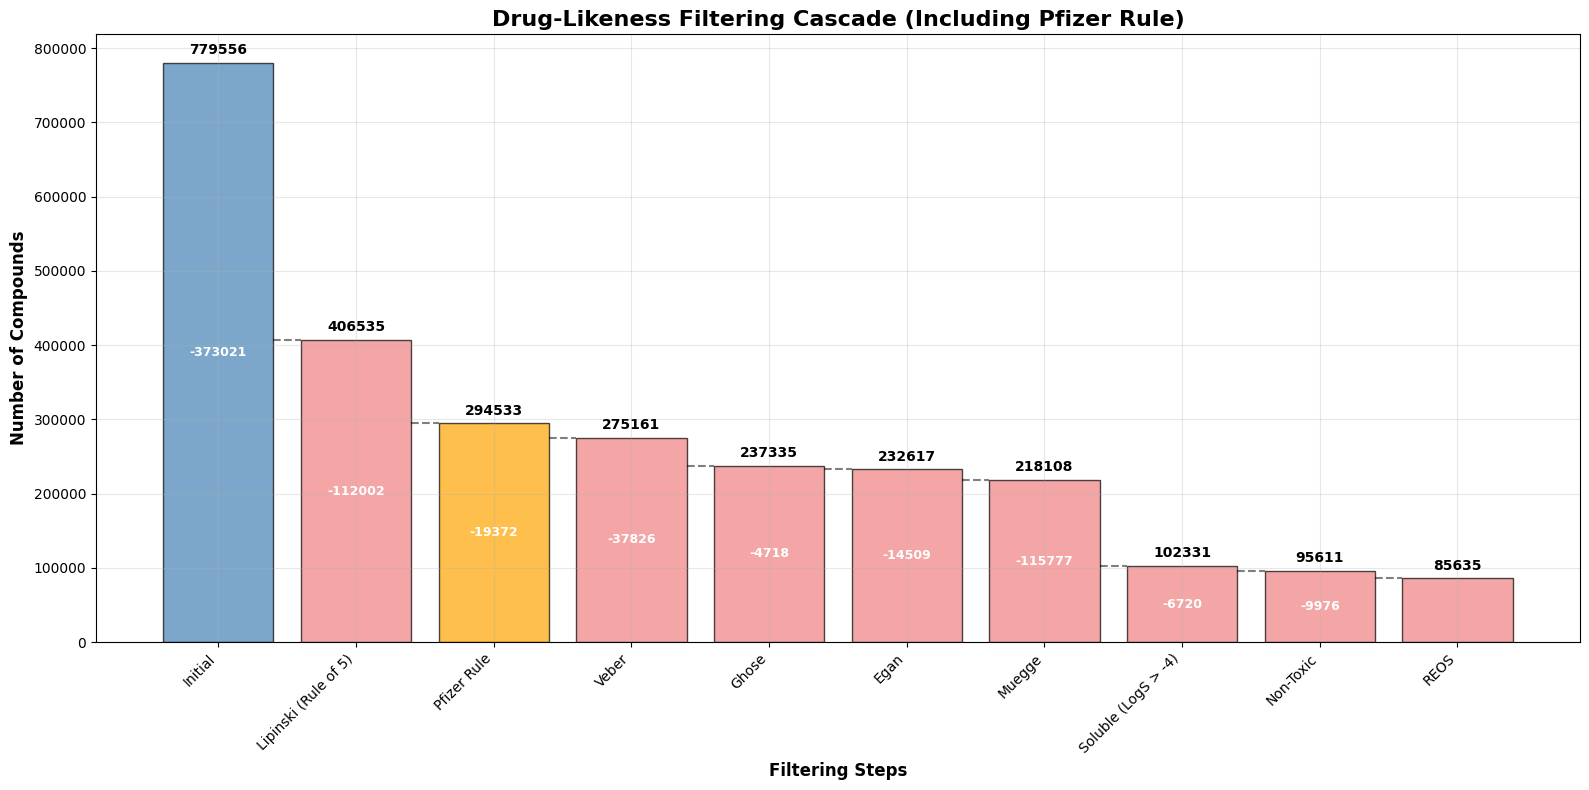


💾 Saving results...
✅ Saved filtered compounds to: filtered_drug_like_compounds_with_pfizer.csv

📝 Generating summary report...
✅ Saved analysis summary to: drug_analysis_summary_with_pfizer.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Saved: panel_filtering_efficiency_pie_with_pfizer.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Saved: panel_pfizer_rule_impact.png
🎉 All panels saved as PNGs (including Pfizer Rule visualizations).


In [ ]:
# -*- coding: utf-8 -*-
"""Part-2_Property_based_filtering.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1D2OnxxiCQ8kBLbuKteUJZqwC50LlbfxM
"""

!pip install rdkit-pypi

# @title Property based filtering with Pfizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
import warnings
warnings.filterwarnings('ignore')

# --- ADD UPLOAD SECTION HERE ---
from google.colab import files
import io

print("📁 Please upload your CSV file (must have 'smiles' column):")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"✅ Loaded {len(df)} rows from {filename}")
print("Columns:", list(df.columns))
# --- END OF UPLOAD SECTION ---

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

class DrugAnalyzerSequential:
    def __init__(self, dataframe):
        self.df = dataframe.copy()
        self.original_count = len(dataframe)
        self.filtering_results = {}

    def calculate_properties(self):
        """Calculate molecular properties for all compounds"""
        print("🧮 Calculating molecular properties...")

        properties = []
        invalid_smiles = 0

        for idx, smiles in enumerate(self.df['smiles']):
            try:
                mol = Chem.MolFromSmiles(str(smiles)) if pd.notna(smiles) else None

                if mol is None:
                    invalid_smiles += 1
                    prop = {key: np.nan for key in ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Rings', 'HeavyAtoms', 'LogS']}
                else:
                    # Calculate all molecular descriptors
                    prop = {
                        'MW': Descriptors.MolWt(mol),
                        'LogP': Crippen.MolLogP(mol),
                        'HBD': Lipinski.NumHDonors(mol),
                        'HBA': Lipinski.NumHAcceptors(mol),
                        'TPSA': Descriptors.TPSA(mol),
                        'RotBonds': Descriptors.NumRotatableBonds(mol),
                        'Rings': rdMolDescriptors.CalcNumRings(mol),
                        'HeavyAtoms': mol.GetNumHeavyAtoms(),
                        'LogS': self.calculate_logS(mol)  # Improved LogS calculation
                    }

            except Exception as e:
                invalid_smiles += 1
                prop = {key: np.nan for key in ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Rings', 'HeavyAtoms', 'LogS']}

            properties.append(prop)

            # Progress indicator
            if (idx + 1) % 100 == 0:
                print(f"  Processed {idx + 1}/{len(self.df)} compounds...")

        # Add properties to dataframe
        for key in properties[0].keys():
            self.df[key] = [prop[key] for prop in properties]

        print(f"✅ Properties calculated! ({invalid_smiles} invalid SMILES found)")
        return self.df

    def calculate_logS(self, mol):
        """Improved LogS calculation using ESOL method"""
        try:
            # ESOL (Estimated SOLubility) method
            logP = Crippen.MolLogP(mol)
            MW = Descriptors.MolWt(mol)
            RB = Descriptors.NumRotatableBonds(mol)
            AP = rdMolDescriptors.CalcNumAromaticRings(mol)

            # ESOL equation
            logS = 0.16 - 0.63*logP - 0.0062*MW + 0.066*RB - 0.74*AP
            return logS
        except:
            return np.nan

    def apply_rule_filter(self, df, rule_name, conditions):
        """Apply a set of conditions and return filtered dataframe"""
        try:
            # Combine all conditions with AND logic
            combined_mask = np.ones(len(df), dtype=bool)
            for condition in conditions:
                # Handle NaN values by treating them as failures
                condition_mask = condition.fillna(False) if hasattr(condition, 'fillna') else condition
                combined_mask = combined_mask & condition_mask

            filtered_df = df.loc[combined_mask].copy()
            passed_count = len(filtered_df)
            failed_count = len(df) - passed_count

            print(f"  {rule_name}: {passed_count} passed, {failed_count} failed")
            return filtered_df

        except Exception as e:
            print(f"  Error in {rule_name} filter: {e}")
            return df

    def apply_pfizer_rule_filter(self, df):
        """Apply Pfizer Rule filter - removes compounds with LogP > 3 AND TPSA < 75 (potentially toxic)"""
        print("Applying Pfizer Rule filter...")

        # Pfizer Rule: Filter OUT compounds with LogP > 3 AND TPSA < 75
        # These compounds are considered potentially toxic
        pfizer_toxic_mask = (df['LogP'] > 3) & (df['TPSA'] < 75)

        # Keep compounds that do NOT meet the toxic criteria
        safe_mask = ~pfizer_toxic_mask.fillna(False)
        filtered_df = df.loc[safe_mask].copy()

        passed_count = len(filtered_df)
        failed_count = len(df) - passed_count

        print(f"  Pfizer Rule: {passed_count} passed, {failed_count} failed (potentially toxic compounds removed)")
        return filtered_df

    def apply_REOS_filter(self, df):
        """Apply REOS (Rapid Elimination Of Swill) filter"""
        print("🚫 Applying REOS filter...")

        # REOS unwanted substructures
        REOS_patterns = [
            '[#7][#7]',           # Azo groups
            '[#6]=[#7][#7]',      # Hydrazones
            '[#16]=[#16]',        # Disulfides
            '[#7]=[#7]',          # Azo
            '[#6]#[#7]',          # Nitriles (optional)
            '[#7][#16]',          # N-S bonds
            '[#16]=[#8]',         # Sulfoxides
            '[#15]',              # Phosphorus
            '[#9,#17,#35,#53]',   # Halogens (optional, can be removed)
            '[#33,#51,#83]',      # Metalloids
        ]

        reos_flags = []
        for smiles in df['smiles']:
            try:
                mol = Chem.MolFromSmiles(str(smiles)) if pd.notna(smiles) else None
                passes_reos = True

                if mol is not None:
                    for pattern in REOS_patterns:
                        try:
                            if mol.HasSubstructMatch(Chem.MolFromSmarts(pattern)):
                                passes_reos = False
                                break
                        except:
                            continue
                else:
                    passes_reos = False

                reos_flags.append(passes_reos)

            except Exception as e:
                reos_flags.append(False)

        filtered_df = df.loc[reos_flags].copy()
        passed_count = len(filtered_df)
        failed_count = len(df) - passed_count

        print(f"  REOS filter: {passed_count} passed, {failed_count} failed")
        return filtered_df

    def predict_toxicity_filter(self, df):
        """Apply toxicity prediction filter"""
        print("☠️ Applying toxicity filter...")

        # Structural alerts for toxicity
        toxic_patterns = [
            '[N+](=O)[O-]',       # Nitro groups
            '[CH]=O',             # Aldehydes
            'C1OC1',              # Epoxides
            'c[NH2]',             # Aromatic amines
            'N-N',                # Hydrazines
            '[SH]',               # Thiols
            'C=C-C=O',            # α,β-unsaturated carbonyls
            '[Cl,Br,I][CH2]',     # Alkyl halides
        ]

        toxicity_scores = []
        for idx, smiles in enumerate(df['smiles']):
            try:
                mol = Chem.MolFromSmiles(str(smiles)) if pd.notna(smiles) else None
                score = 0

                if mol is not None:
                    # Check structural alerts
                    for pattern in toxic_patterns:
                        try:
                            if mol.HasSubstructMatch(Chem.MolFromSmarts(pattern)):
                                score += 1
                        except:
                            continue

                    # Additional property-based toxicity indicators
                    row_idx = df.index[idx]
                    if not pd.isna(df.loc[row_idx, 'MW']) and df.loc[row_idx, 'MW'] > 800:
                        score += 1
                    if not pd.isna(df.loc[row_idx, 'LogP']) and df.loc[row_idx, 'LogP'] > 6:
                        score += 1
                    if not pd.isna(df.loc[row_idx, 'TPSA']) and df.loc[row_idx, 'TPSA'] > 200:
                        score += 1

                toxicity_scores.append(score)

            except Exception as e:
                toxicity_scores.append(10)  # Assume toxic if error

        # Filter out compounds with toxicity score >= 2
        df['Toxicity_Score'] = toxicity_scores
        filtered_df = df.loc[df['Toxicity_Score'] < 2].copy()

        passed_count = len(filtered_df)
        failed_count = len(df) - passed_count

        print(f"  Toxicity filter: {passed_count} passed, {failed_count} failed")
        return filtered_df

    def analyze_sequential(self):
        """Perform sequential drug-likeness filtering"""
        print("🔬 Starting sequential drug-likeness analysis...")
        print(f"📊 Initial dataset: {self.original_count} compounds\n")

        # Calculate properties
        self.calculate_properties()

        # Remove compounds with missing critical properties
        initial_df = self.df.dropna(subset=['MW', 'LogP', 'HBD', 'HBA']).copy()
        print(f"After removing invalid compounds: {len(initial_df)} compounds\n")

        current_df = initial_df.copy()
        self.filtering_results['Initial'] = len(current_df)

        # Apply Lipinski Rule first
        print("Applying Lipinski (Rule of 5)...")
        lipinski_conditions = [
            current_df['MW'] <= 500,
            current_df['LogP'] <= 5,
            current_df['HBD'] <= 5,
            current_df['HBA'] <= 10
        ]
        current_df = self.apply_rule_filter(current_df, 'Lipinski (Rule of 5)', lipinski_conditions)
        self.filtering_results['Lipinski (Rule of 5)'] = len(current_df)

        # Apply Pfizer Rule after Lipinski
        current_df = self.apply_pfizer_rule_filter(current_df)
        self.filtering_results['Pfizer Rule'] = len(current_df)

        # Define remaining drug-likeness rules
        rules_config = {
            'Veber': {
                'TPSA': ('<=', 140),
                'RotBonds': ('<=', 10)
            },
            'Ghose': {
                'MW': ('range', 160, 480),
                'LogP': ('range', -0.4, 5.6),
                'HeavyAtoms': ('<=', 50)
            },
            'Egan': {
                'TPSA': ('<=', 131.6),
                'LogP': ('range', -1, 6)
            },
            'Muegge': {
                'MW': ('range', 200, 600),
                'LogP': ('range', -2, 5),
                'TPSA': ('<=', 150),
                'Rings': ('<=', 7),
                'HBD': ('<=', 5),
                'HBA': ('<=', 10),
                'RotBonds': ('<=', 15)
            }
        }

        # Apply remaining rules sequentially
        for rule_name, rule_conditions in rules_config.items():
            print(f"Applying {rule_name}...")

            # Build conditions for current dataframe
            conditions = []
            for prop, condition in rule_conditions.items():
                if condition[0] == '<=':
                    conditions.append(current_df[prop] <= condition[1])
                elif condition[0] == '>=':
                    conditions.append(current_df[prop] >= condition[1])
                elif condition[0] == 'range':
                    conditions.append((current_df[prop] >= condition[1]) & (current_df[prop] <= condition[2]))

            current_df = self.apply_rule_filter(current_df, rule_name, conditions)
            self.filtering_results[rule_name] = len(current_df)

        # Apply solubility filter
        print("Applying Solubility filter...")
        soluble_mask = current_df['LogS'] > -4
        current_df = current_df.loc[soluble_mask.fillna(False)].copy()
        self.filtering_results['Soluble (LogS > -4)'] = len(current_df)
        print(f"  Solubility filter: {len(current_df)} passed")

        # Apply toxicity filter
        current_df = self.predict_toxicity_filter(current_df)
        self.filtering_results['Non-Toxic'] = len(current_df)

        # Apply REOS filter
        current_df = self.apply_REOS_filter(current_df)
        self.filtering_results['REOS'] = len(current_df)

        print(f"\n✅ Sequential filtering complete!")
        print(f"📊 Final result: {len(current_df)} compounds passed all filters")
        print(f"📉 Filtering efficiency: {len(current_df)/self.original_count*100:.1f}%")

        return current_df, self.filtering_results

    def create_visualizations(self, final_df, filtering_results):
        """Create comprehensive visualizations"""
        print("\n📊 Creating visualizations...")

        # Set up the plotting area
        fig = plt.figure(figsize=(22, 18))

        # 1. Filtering cascade plot
        plt.subplot(4, 4, 1)
        steps = list(filtering_results.keys())
        counts = list(filtering_results.values())
        colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))

        bars = plt.bar(range(len(steps)), counts, color=colors)
        plt.title('Sequential Filtering Results', fontsize=14, fontweight='bold')
        plt.xlabel('Filtering Step')
        plt.ylabel('Number of Compounds')
        plt.xticks(range(len(steps)), steps, rotation=45, ha='right')

        # Add value labels on bars
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                    str(count), ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()

        # 2. Property distributions (before and after)
        properties = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds']

        for i, prop in enumerate(properties):
            plt.subplot(4, 4, i+2)

            # Original data
            original_data = self.df[prop].dropna()
            final_data = final_df[prop].dropna()

            if len(original_data) > 0:
                plt.hist(original_data, bins=30, alpha=0.5, label='Original', color='lightcoral', density=True)
            if len(final_data) > 0:
                plt.hist(final_data, bins=30, alpha=0.7, label='Filtered', color='steelblue', density=True)

            plt.title(f'{prop} Distribution', fontweight='bold')
            plt.xlabel(prop)
            plt.ylabel('Density')
            plt.legend()
            plt.grid(True, alpha=0.3)

        # 3. Correlation heatmap
        plt.subplot(4, 4, 8)
        correlation_props = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'LogS']
        available_props = [prop for prop in correlation_props if prop in final_df.columns]

        if len(available_props) > 1 and len(final_df) > 1:
            corr_matrix = final_df[available_props].corr()
            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                       square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title('Property Correlations (Filtered Data)', fontweight='bold')

        # 4. Drug-likeness space plot
        plt.subplot(4, 4, 9)
        original_mw = self.df['MW'].dropna()
        original_logp = self.df['LogP'].dropna()
        final_mw = final_df['MW'].dropna()
        final_logp = final_df['LogP'].dropna()

        if len(original_mw) > 0 and len(original_logp) > 0:
            plt.scatter(original_mw, original_logp, alpha=0.5, s=20, color='lightcoral', label='Original')
        if len(final_mw) > 0 and len(final_logp) > 0:
            plt.scatter(final_mw, final_logp, alpha=0.8, s=30, color='steelblue', label='Filtered')

        # Add Lipinski boundaries
        plt.axvline(x=500, color='red', linestyle='--', alpha=0.7, label='MW=500')
        plt.axhline(y=5, color='red', linestyle='--', alpha=0.7, label='LogP=5')

        plt.xlabel('Molecular Weight')
        plt.ylabel('LogP')
        plt.title('Drug-likeness Space (MW vs LogP)', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 5. Pfizer Rule visualization (NEW)
        plt.subplot(4, 4, 10)
        original_logp = self.df['LogP'].dropna()
        original_tpsa = self.df['TPSA'].dropna()
        final_logp_pfizer = final_df['LogP'].dropna()
        final_tpsa_pfizer = final_df['TPSA'].dropna()

        if len(original_logp) > 0 and len(original_tpsa) > 0:
            plt.scatter(original_logp, original_tpsa, alpha=0.5, s=20, color='lightcoral', label='Original')
        if len(final_logp_pfizer) > 0 and len(final_tpsa_pfizer) > 0:
            plt.scatter(final_logp_pfizer, final_tpsa_pfizer, alpha=0.8, s=30, color='steelblue', label='Filtered')

        # Add Pfizer Rule boundaries (toxic region)
        plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='LogP=3')
        plt.axhline(y=75, color='red', linestyle='--', alpha=0.7, label='TPSA=75')

        # Highlight toxic region
        plt.fill([3, plt.xlim()[1], plt.xlim()[1], 3], [0, 0, 75, 75],
                 color='red', alpha=0.1, label='Pfizer Toxic Zone')

        plt.xlabel('LogP')
        plt.ylabel('TPSA')
        plt.title('Pfizer Rule Space (LogP vs TPSA)', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 6. Solubility vs Permeability
        plt.subplot(4, 4, 11)
        final_logs = final_df['LogS'].dropna()
        final_tpsa = final_df['TPSA'].dropna()

        if len(final_logs) > 0 and len(final_tpsa) > 0:
            plt.scatter(final_logs, final_tpsa, alpha=0.7, s=30, color='green')

        plt.axvline(x=-4, color='red', linestyle='--', alpha=0.7, label='LogS=-4')
        plt.axhline(y=140, color='red', linestyle='--', alpha=0.7, label='TPSA=140')

        plt.xlabel('LogS (Solubility)')
        plt.ylabel('TPSA (Permeability)')
        plt.title('Solubility vs Permeability', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 7. Summary statistics
        plt.subplot(4, 4, 12)
        plt.axis('off')

        # Calculate summary stats carefully to handle empty DataFrame or NaN values
        mean_mw = final_df['MW'].mean() if len(final_df) > 0 and not final_df['MW'].dropna().empty else 'N/A'
        mean_logp = final_df['LogP'].mean() if len(final_df) > 0 and not final_df['LogP'].dropna().empty else 'N/A'
        mean_tpsa = final_df['TPSA'].mean() if len(final_df) > 0 and not final_df['TPSA'].dropna().empty else 'N/A'
        mean_logs = final_df['LogS'].mean() if len(final_df) > 0 and not final_df['LogS'].dropna().empty else 'N/A'

        # Format values only if they are numbers, otherwise keep 'N/A'
        mean_mw_str = f"{mean_mw:.1f}" if isinstance(mean_mw, (int, float)) else mean_mw
        mean_logp_str = f"{mean_logp:.2f}" if isinstance(mean_logp, (int, float)) else mean_logp
        mean_tpsa_str = f"{mean_tpsa:.1f}" if isinstance(mean_tpsa, (int, float)) else mean_tpsa
        mean_logs_str = f"{mean_logs:.2f}" if isinstance(mean_logs, (int, float)) else mean_logs

        summary_text = f"""
        FILTERING SUMMARY

        Initial compounds: {self.original_count}
        Final compounds: {len(final_df)}
        Success rate: {len(final_df)/self.original_count*100:.1f}%

        FINAL DATASET STATS
        Mean MW: {mean_mw_str}
        Mean LogP: {mean_logp_str}
        Mean TPSA: {mean_tpsa_str}
        Mean LogS: {mean_logs_str}

        DRUG-LIKENESS
        Lipinski compliant: {len(final_df)}
        Pfizer Rule passed: {len(final_df)}
        Veber compliant: {len(final_df)}
        Non-toxic: {len(final_df)}
        REOS clean: {len(final_df)}
        """

        plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

        # 8. Filtering efficiency pie chart
        plt.subplot(4, 4, 13)
        passed = len(final_df)
        failed = self.original_count - passed

        plt.pie([passed, failed], labels=['Passed', 'Failed'],
               colors=['lightgreen', 'lightcoral'], autopct='%1.1f%%',
               startangle=90)
        plt.title('Overall Filtering Efficiency', fontweight='bold')

        # 9. Pfizer Rule impact visualization (NEW)
        plt.subplot(4, 4, 14)
        if 'Lipinski (Rule of 5)' in filtering_results and 'Pfizer Rule' in filtering_results:
            lipinski_count = filtering_results['Lipinski (Rule of 5)']
            pfizer_count = filtering_results['Pfizer Rule']
            pfizer_removed = lipinski_count - pfizer_count

            categories = ['After Lipinski', 'Pfizer Removed', 'After Pfizer']
            values = [lipinski_count, pfizer_removed, pfizer_count]
            colors = ['lightgreen', 'red', 'darkgreen']

            bars = plt.bar(categories, values, color=colors, alpha=0.7)
            plt.title('Pfizer Rule Impact', fontweight='bold')
            plt.ylabel('Number of Compounds')
            plt.xticks(rotation=45)

            # Add value labels
            for bar, value in zip(bars, values):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                        str(value), ha='center', va='bottom', fontweight='bold')

        # 10. Rule comparison stacked bar (NEW)
        plt.subplot(4, 4, 15)
        rule_names = ['Lipinski', 'Pfizer', 'Veber', 'Ghose', 'Egan', 'Muegge']
        rule_keys = ['Lipinski (Rule of 5)', 'Pfizer Rule', 'Veber', 'Ghose', 'Egan', 'Muegge']

        passed_counts = []
        failed_counts = []

        prev_count = self.original_count
        for rule_key in rule_keys:
            if rule_key in filtering_results:
                current_count = filtering_results[rule_key]
                failed = prev_count - current_count
                passed_counts.append(current_count)
                failed_counts.append(failed)
                prev_count = current_count
            else:
                passed_counts.append(0)
                failed_counts.append(0)

        x = np.arange(len(rule_names))
        width = 0.35

        p1 = plt.bar(x, passed_counts, width, label='Passed', color='lightgreen', alpha=0.7)
        p2 = plt.bar(x, failed_counts, width, bottom=passed_counts, label='Failed', color='lightcoral', alpha=0.7)

        plt.xlabel('Drug-likeness Rules')
        plt.ylabel('Number of Compounds')
        plt.title('Rule-by-Rule Filtering Results', fontweight='bold')
        plt.xticks(x, rule_names, rotation=45)
        plt.legend()

        # 11. Property ranges comparison (NEW)
        plt.subplot(4, 4, 16)
        if len(final_df) > 0:
            props_to_compare = ['MW', 'LogP', 'TPSA']
            prop_ranges = {}

            for prop in props_to_compare:
                if prop in final_df.columns:
                    data = final_df[prop].dropna()
                    if len(data) > 0:
                        prop_ranges[prop] = [data.min(), data.max(), data.mean()]

            if prop_ranges:
                props = list(prop_ranges.keys())
                mins = [prop_ranges[prop][0] for prop in props]
                maxs = [prop_ranges[prop][1] for prop in props]
                means = [prop_ranges[prop][2] for prop in props]

                x = np.arange(len(props))
                width = 0.25

                plt.bar(x - width, mins, width, label='Min', alpha=0.7)
                plt.bar(x, means, width, label='Mean', alpha=0.7)
                plt.bar(x + width, maxs, width, label='Max', alpha=0.7)

                plt.xlabel('Properties')
                plt.ylabel('Values')
                plt.title('Final Dataset Property Ranges', fontweight='bold')
                plt.xticks(x, props)
                plt.legend()

        plt.tight_layout()
        plt.show()

        # Create a detailed filtering cascade plot
        self.create_cascade_plot(filtering_results)

    def create_cascade_plot(self, filtering_results):
        """Create a detailed cascade/waterfall plot"""
        fig, ax = plt.subplots(figsize=(16, 8))

        steps = list(filtering_results.keys())
        counts = list(filtering_results.values())

        # Calculate drops
        drops = [counts[i] - counts[i+1] if i < len(counts)-1 else 0 for i in range(len(counts))]

        # Create waterfall effect
        x_pos = range(len(steps))
        colors = ['steelblue' if i == 0 else 'orange' if 'Pfizer' in steps[i] else 'lightcoral' for i in range(len(steps))]

        bars = ax.bar(x_pos, counts, color=colors, alpha=0.7, edgecolor='black')

        # Add connecting lines
        for i in range(len(steps)-1):
            if i+1 < len(x_pos):
                ax.plot([i+0.4, i+0.6], [counts[i+1], counts[i+1]], 'k--', alpha=0.5)

        # Add labels
        for i, (bar, count, drop) in enumerate(zip(bars, counts, drops)):
            # Count label
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                   str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

            # Drop label
            if drop > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                       f'-{drop}', ha='center', va='center',
                       color='white', fontweight='bold', fontsize=9)

        ax.set_xlabel('Filtering Steps', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Compounds', fontsize=12, fontweight='bold')
        ax.set_title('Drug-Likeness Filtering Cascade (Including Pfizer Rule)', fontsize=16, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(steps, rotation=45, ha='right')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def generate_summary_report(self, final_df, filtering_results):
        """Generate detailed text summary report"""
        print("\n📝 Generating summary report...")

        # Create detailed summary
        summary_lines = []
        summary_lines.append("=" * 80)
        summary_lines.append("DRUG-LIKENESS ANALYSIS SUMMARY REPORT (WITH PFIZER RULE)")
        summary_lines.append("=" * 80)
        summary_lines.append("")

        # Overview
        summary_lines.append("OVERVIEW:")
        summary_lines.append("-" * 40)
        summary_lines.append(f"Initial Dataset Size: {self.original_count} compounds")
        summary_lines.append(f"Final Dataset Size: {len(final_df)} compounds")
        summary_lines.append(f"Overall Success Rate: {len(final_df)/self.original_count*100:.2f}%")
        summary_lines.append(f"Compounds Filtered Out: {self.original_count - len(final_df)}")
        summary_lines.append("")

        # Sequential filtering results
        summary_lines.append("SEQUENTIAL FILTERING RESULTS:")
        summary_lines.append("-" * 40)
        prev_count = self.original_count
        for step, count in filtering_results.items():
            removed = prev_count - count
            retention_rate = (count / prev_count * 100) if prev_count > 0 else 0
            summary_lines.append(f"{step:<25}: {count:>6} compounds ({retention_rate:>5.1f}% retained, {removed:>5} removed)")
            prev_count = count
        summary_lines.append("")

        # Property statistics
        if len(final_df) > 0:
            summary_lines.append("FINAL DATASET MOLECULAR PROPERTIES:")
            summary_lines.append("-" * 40)
            properties = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Rings', 'HeavyAtoms', 'LogS']
            for prop in properties:
                if prop in final_df.columns:
                    prop_data = final_df[prop].dropna()
                    if len(prop_data) > 0:
                        summary_lines.append(f"{prop:<12}: Mean={prop_data.mean():>7.2f}, Std={prop_data.std():>7.2f}, Min={prop_data.min():>7.2f}, Max={prop_data.max():>7.2f}")
                    else:
                        summary_lines.append(f"{prop:<12}: No valid data")
            summary_lines.append("")

        # Drug-likeness compliance
        summary_lines.append("DRUG-LIKENESS RULE COMPLIANCE:")
        summary_lines.append("-" * 40)
        if len(final_df) > 0:
            # All compounds in final_df passed all rules by definition
            summary_lines.append(f"Lipinski Rule of 5 Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Pfizer Rule Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Veber Rule Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Ghose Rule Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Egan Rule Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Muegge Rule Compliant: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"Non-Toxic: {len(final_df)} compounds (100.0%)")
            summary_lines.append(f"REOS Clean: {len(final_df)} compounds (100.0%)")
        else:
            summary_lines.append("No compounds passed all filters")
        summary_lines.append("")

        # Detailed rule descriptions
        summary_lines.append("DRUG-LIKENESS RULES APPLIED:")
        summary_lines.append("-" * 40)
        summary_lines.append("1. Lipinski Rule of 5:")
        summary_lines.append("   - Molecular Weight ≤ 500 Da")
        summary_lines.append("   - LogP ≤ 5")
        summary_lines.append("   - Hydrogen Bond Donors ≤ 5")
        summary_lines.append("   - Hydrogen Bond Acceptors ≤ 10")
        summary_lines.append("")
        summary_lines.append("2. Pfizer Rule (Toxicity Filter):")
        summary_lines.append("   - Removes compounds with LogP > 3 AND TPSA < 75")
        summary_lines.append("   - These compounds are considered potentially toxic")
        summary_lines.append("   - Applied after Lipinski filtering")
        summary_lines.append("")
        summary_lines.append("3. Veber Rule:")
        summary_lines.append("   - Topological Polar Surface Area ≤ 140 Ų")
        summary_lines.append("   - Rotatable Bonds ≤ 10")
        summary_lines.append("")
        summary_lines.append("4. Ghose Rule:")
        summary_lines.append("   - Molecular Weight: 160-480 Da")
        summary_lines.append("   - LogP: -0.4 to 5.6")
        summary_lines.append("   - Heavy Atoms ≤ 50")
        summary_lines.append("")
        summary_lines.append("5. Egan Rule:")
        summary_lines.append("   - TPSA ≤ 131.6 Ų")
        summary_lines.append("   - LogP: -1 to 6")
        summary_lines.append("")
        summary_lines.append("6. Muegge Rule:")
        summary_lines.append("   - Molecular Weight: 200-600 Da")
        summary_lines.append("   - LogP: -2 to 5")
        summary_lines.append("   - TPSA ≤ 150 Ų")
        summary_lines.append("   - Rings ≤ 7")
        summary_lines.append("   - HBD ≤ 5, HBA ≤ 10")
        summary_lines.append("   - Rotatable Bonds ≤ 15")
        summary_lines.append("")
        summary_lines.append("7. Solubility Filter:")
        summary_lines.append("   - LogS > -4 (soluble compounds)")
        summary_lines.append("")
        summary_lines.append("8. Toxicity Filter:")
        summary_lines.append("   - Removes compounds with known toxic substructures")
        summary_lines.append("   - Filters based on structural alerts")
        summary_lines.append("")
        summary_lines.append("9. REOS Filter:")
        summary_lines.append("   - Rapid Elimination of Swill")
        summary_lines.append("   - Removes reactive and problematic substructures")
        summary_lines.append("")

        # Pfizer Rule Impact Analysis
        if 'Lipinski (Rule of 5)' in filtering_results and 'Pfizer Rule' in filtering_results:
            lipinski_count = filtering_results['Lipinski (Rule of 5)']
            pfizer_count = filtering_results['Pfizer Rule']
            pfizer_removed = lipinski_count - pfizer_count
            pfizer_impact = (pfizer_removed / lipinski_count * 100) if lipinski_count > 0 else 0

            summary_lines.append("PFIZER RULE IMPACT ANALYSIS:")
            summary_lines.append("-" * 40)
            summary_lines.append(f"Compounds after Lipinski: {lipinski_count}")
            summary_lines.append(f"Compounds removed by Pfizer Rule: {pfizer_removed}")
            summary_lines.append(f"Pfizer Rule impact: {pfizer_impact:.1f}% of Lipinski-compliant compounds")
            summary_lines.append(f"Compounds after Pfizer Rule: {pfizer_count}")
            summary_lines.append("")

        # Analysis conclusions
        summary_lines.append("ANALYSIS CONCLUSIONS:")
        summary_lines.append("-" * 40)
        if len(final_df) > 0:
            success_rate = len(final_df)/self.original_count*100
            if success_rate > 20:
                summary_lines.append("✅ GOOD: High retention rate suggests quality input dataset")
            elif success_rate > 5:
                summary_lines.append("⚠️  MODERATE: Moderate retention rate, some optimization may be needed")
            else:
                summary_lines.append("❌ LOW: Low retention rate suggests input dataset needs improvement")

            summary_lines.append(f"Final dataset contains {len(final_df)} drug-like compounds")
            summary_lines.append("All compounds passed comprehensive drug-likeness filters including Pfizer Rule")
            summary_lines.append("Ready for further drug discovery applications")
        else:
            summary_lines.append("❌ CRITICAL: No compounds passed all filters")
            summary_lines.append("Consider relaxing filter criteria or improving input dataset quality")

        summary_lines.append("")
        summary_lines.append("=" * 80)
        summary_lines.append("END OF REPORT")
        summary_lines.append("=" * 80)

        # Join all lines
        summary_text = "\n".join(summary_lines)

        return summary_text

    def save_results(self, final_df, filtering_results):
        """Save CSV and summary text files"""
        print("\n💾 Saving results...")

        # Save filtered compounds to CSV
        csv_filename = "filtered_drug_like_compounds_with_pfizer.csv"
        final_df.to_csv(csv_filename, index=False)
        print(f"✅ Saved filtered compounds to: {csv_filename}")

        # Generate and save summary report
        summary_text = self.generate_summary_report(final_df, filtering_results)
        txt_filename = "drug_analysis_summary_with_pfizer.txt"
        with open(txt_filename, 'w') as f:
            f.write(summary_text)
        print(f"✅ Saved analysis summary to: {txt_filename}")

        # Download files in Colab
        try:
            files.download(csv_filename)
            files.download(txt_filename)
            print("📥 Files downloaded successfully!")
        except Exception as e:
            print(f"⚠️  Download error: {e}")
            print("Files are saved in the current directory")

        return csv_filename, txt_filename

# ==============================
# YOUR CODE STARTS HERE 👇👇👇
# ==============================

# Run the analysis on the uploaded dataframe 'df'
analyzer = DrugAnalyzerSequential(df)
final_df, filtering_results = analyzer.analyze_sequential()
analyzer.create_visualizations(final_df, filtering_results)

# Save results to files
csv_file, txt_file = analyzer.save_results(final_df, filtering_results)

print(f"\n🎉 Analysis Complete!")
print(f"📊 Final Results: {len(final_df)} compounds passed all filters")
print(f"📁 Output Files:")
print(f"   - CSV: {csv_file}")
print(f"   - Summary: {txt_file}")

# Display first few rows of final results
if len(final_df) > 0:
    print(f"\n📋 Preview of Final Dataset (first 5 compounds):")
    display_cols = ['smiles', 'MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'LogS']
    available_cols = [col for col in display_cols if col in final_df.columns]
    print(final_df[available_cols].head())
else:
    print("\n❌ No compounds passed all filters")

# ==============================
# YOUR CODE ENDS HERE 👆👆👆
# ==============================

# @title Download All PNG files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Import pandas

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

def save_and_download(fig, filename, dpi=300):
    fig.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    if COLAB:
        try:
            files.download(filename)
        except Exception as e:
            print(f"Download error: {e}")
    print(f"✅ Saved: {filename}")

# Modified function signature to accept the dataframe containing calculated properties
def generate_and_save_all_visualizations(original_df_with_properties, final_df, filtering_results, original_count):
    # 1. Filtering cascade plot
    fig1 = plt.figure(figsize=(10, 6))
    steps = list(filtering_results.keys())
    counts = list(filtering_results.values())
    colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))
    bars = plt.bar(range(len(steps)), counts, color=colors)
    plt.title('Sequential Filtering Results (Including Pfizer Rule)', fontsize=14, fontweight='bold')
    plt.xlabel('Filtering Step')
    plt.ylabel('Number of Compounds')
    plt.xticks(range(len(steps)), steps, rotation=45, ha='right')
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                str(count), ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    save_and_download(fig1, 'panel_filtering_cascade_with_pfizer.png')

    # 2. Property distributions (before and after)
    properties = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds']
    for prop in properties:
        # Check if the property column exists in both dataframes
        if prop in original_df_with_properties.columns and prop in final_df.columns:
            fig2 = plt.figure(figsize=(8, 6))
            # Use the dataframe with calculated properties for 'Original' data
            original_data = original_df_with_properties[prop].dropna()
            final_data = final_df[prop].dropna()
            if len(original_data) > 0:
                plt.hist(original_data, bins=30, alpha=0.5, label='Original', color='lightcoral', density=True)
            if len(final_data) > 0:
                plt.hist(final_data, bins=30, alpha=0.7, label='Filtered', color='steelblue', density=True)
            plt.title(f'{prop} Distribution', fontweight='bold')
            plt.xlabel(prop)
            plt.ylabel('Density')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            save_and_download(fig2, f'panel_hist_{prop}_with_pfizer.png')
        else:
            print(f"Warning: Property '{prop}' not found in one or both dataframes. Skipping histogram.")

    # 3. Correlation heatmap
    fig3 = plt.figure(figsize=(8, 6))
    correlation_props = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'LogS']
    # Ensure properties exist in final_df before trying to correlate
    available_props = [prop for prop in correlation_props if prop in final_df.columns]

    if len(available_props) > 1 and len(final_df) > 1:
        # Calculate correlations only for available and numeric properties
        corr_matrix = final_df[available_props].corr(numeric_only=True)
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                   square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title('Property Correlations (Filtered Data)', fontweight='bold')
        plt.tight_layout()
        save_and_download(fig3, 'panel_correlation_heatmap_with_pfizer.png')
    else:
         print("Warning: Not enough numeric columns in final_df to plot correlation heatmap.")

    # 4. Drug-likeness space plot
    fig4 = plt.figure(figsize=(8, 6))
    # Use the dataframe with calculated properties for 'Original' data
    # Check if MW and LogP exist before plotting
    if 'MW' in original_df_with_properties.columns and 'LogP' in original_df_with_properties.columns:
        original_mw = original_df_with_properties['MW'].dropna()
        original_logp = original_df_with_properties['LogP'].dropna()
        if len(original_mw) > 0 and len(original_logp) > 0:
            plt.scatter(original_mw, original_logp, alpha=0.5, s=20, color='lightcoral', label='Original')
    else:
        print("Warning: 'MW' or 'LogP' not found in original_df_with_properties. Skipping original scatter points.")

    if 'MW' in final_df.columns and 'LogP' in final_df.columns:
        final_mw = final_df['MW'].dropna()
        final_logp = final_df['LogP'].dropna()
        if len(final_mw) > 0 and len(final_logp) > 0:
            plt.scatter(final_mw, final_logp, alpha=0.8, s=30, color='steelblue', label='Filtered')
    else:
         print("Warning: 'MW' or 'LogP' not found in final_df. Skipping filtered scatter points.")

    # Add Lipinski boundaries
    plt.axvline(x=500, color='red', linestyle='--', alpha=0.7, label='MW=500')
    plt.axhline(y=5, color='red', linestyle='--', alpha=0.7, label='LogP=5')

    plt.xlabel('Molecular Weight')
    plt.ylabel('LogP')
    plt.title('Drug-likeness Space (MW vs LogP)', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_and_download(fig4, 'panel_druglikeness_space_with_pfizer.png')

    # 5. NEW: Pfizer Rule visualization
    fig5 = plt.figure(figsize=(8, 6))
    if 'LogP' in original_df_with_properties.columns and 'TPSA' in original_df_with_properties.columns:
        original_logp = original_df_with_properties['LogP'].dropna()
        original_tpsa = original_df_with_properties['TPSA'].dropna()
        if len(original_logp) > 0 and len(original_tpsa) > 0:
            plt.scatter(original_logp, original_tpsa, alpha=0.5, s=20, color='lightcoral', label='Original')

    if 'LogP' in final_df.columns and 'TPSA' in final_df.columns:
        final_logp_pfizer = final_df['LogP'].dropna()
        final_tpsa_pfizer = final_df['TPSA'].dropna()
        if len(final_logp_pfizer) > 0 and len(final_tpsa_pfizer) > 0:
            plt.scatter(final_logp_pfizer, final_tpsa_pfizer, alpha=0.8, s=30, color='steelblue', label='Filtered')

    # Add Pfizer Rule boundaries (toxic region)
    plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='LogP=3')
    plt.axhline(y=75, color='red', linestyle='--', alpha=0.7, label='TPSA=75')

    # Highlight toxic region
    plt.fill([3, plt.xlim()[1], plt.xlim()[1], 3], [0, 0, 75, 75],
             color='red', alpha=0.1, label='Pfizer Toxic Zone')

    plt.xlabel('LogP')
    plt.ylabel('TPSA')
    plt.title('Pfizer Rule Space (LogP vs TPSA)', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_and_download(fig5, 'panel_pfizer_rule_space.png')

    # 6. Solubility vs Permeability
    fig6 = plt.figure(figsize=(8, 6))
    # Check if LogS and TPSA exist before plotting
    if 'LogS' in final_df.columns and 'TPSA' in final_df.columns:
        final_logs = final_df['LogS'].dropna()
        final_tpsa = final_df['TPSA'].dropna()
        if len(final_logs) > 0 and len(final_tpsa) > 0:
            plt.scatter(final_logs, final_tpsa, alpha=0.7, s=30, color='green')

        plt.axvline(x=-4, color='red', linestyle='--', alpha=0.7, label='LogS=-4')
        plt.axhline(y=140, color='red', linestyle='--', alpha=0.7, label='TPSA=140')

        plt.xlabel('LogS (Solubility)')
        plt.ylabel('TPSA (Permeability)')
        plt.title('Solubility vs Permeability', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_and_download(fig6, 'panel_solubility_vs_permeability_with_pfizer.png')
    else:
        print("Warning: 'LogS' or 'TPSA' not found in final_df. Skipping Solubility vs Permeability plot.")

    # 7. Pie Chart
    fig7 = plt.figure(figsize=(8, 6))
    passed = len(final_df)
    failed = original_count - passed
    plt.pie([passed, failed], labels=['Passed', 'Failed'],
           colors=['lightgreen', 'lightcoral'], autopct='%1.1f%%',
           startangle=90)
    plt.title('Overall Filtering Efficiency (With Pfizer Rule)', fontweight='bold')
    plt.tight_layout()
    save_and_download(fig7, 'panel_filtering_efficiency_pie_with_pfizer.png')

    # 8. NEW: Pfizer Rule impact visualization
    fig8 = plt.figure(figsize=(8, 6))
    if 'Lipinski (Rule of 5)' in filtering_results and 'Pfizer Rule' in filtering_results:
        lipinski_count = filtering_results['Lipinski (Rule of 5)']
        pfizer_count = filtering_results['Pfizer Rule']
        pfizer_removed = lipinski_count - pfizer_count

        categories = ['After Lipinski', 'Pfizer Removed', 'After Pfizer']
        values = [lipinski_count, pfizer_removed, pfizer_count]
        colors = ['lightgreen', 'red', 'darkgreen']

        bars = plt.bar(categories, values, color=colors, alpha=0.7)
        plt.title('Pfizer Rule Impact on Filtering', fontweight='bold')
        plt.ylabel('Number of Compounds')
        plt.xticks(rotation=45)

        # Add value labels
        for bar, value in zip(bars, values):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                    str(value), ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        save_and_download(fig8, 'panel_pfizer_rule_impact.png')

    print("🎉 All panels saved as PNGs (including Pfizer Rule visualizations).")

# Update the call site to pass the dataframe with calculated properties (analyzer.df)
generate_and_save_all_visualizations(analyzer.df, final_df, filtering_results, original_count=analyzer.original_count)